## 图像噪声
- 由干图像采集、处理、传输等过程不可避免的会受到噪声的污染，妨碍人们对图像理解及分析处理。常见的图像噪声有高斯噪声、椒盐噪声等。

#### 椒盐噪声
- 椒盐噪声也称为脉冲噪声，是图像中经常见到的一种噪声，它是一种随机出现的白点或者黑点，可能是亮的区域有黑色像素或是在暗的区域有白色像素(或是两者皆有)。盐噪声的成因可能是影像讯号受到突如其来的强烈干扰而产生、类比数位转换器或位元传输错误等。例如失效的感应器导致像素值为最小值，饱和的感应器导致像素值为最大值。

#### 高斯噪声

高斯噪声是指噪声密度函数服从高斯分布的一类噪声。由于高斯噪声在空间和频域中数学上的易处理性，这种噪声也称为正态噪声模型经常被用于实践中。高斯随机变量的概率密度函数如下式给出：

$$p(z) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(z-μ)^2}{2\sigma^2}}$$

其中 $z$ 表示灰度值，$μ$ 表示的平均值或期望值，$\sigma$ 表示$z$的标准差。标准差的平方 $\sigma^2$ 称为 z 的方差。高斯函数的曲线如图所示。

![高斯](picture/高斯.png)

# 图像平滑
- 图像平滑从信号处理的角度看就是去除其中的高频信息，保留低频信息。因此我们可以对图像实施低通滤波。低通滤波可以去除图像中的噪声，对图像进行平滑。
- 根据滤波器的不同可分为均值滤波，高斯滤波，中值滤波，双边滤波。
- 图像模糊化的作用
- 自定义卷积核

卷积核可视化：https://setosa.io/ev/image-kernels/

在卷积过程中，当没有边界填充时，卷积后输出图像的宽度（或高度）可以通过以下公式计算：

### 公式：
$$
W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} - F}{S} \right\rfloor + 1
$$

### 参数说明：
- $ W_{\text{in}} $：输入图像的宽度（或高度）。
- $ F $：卷积核的宽度（或高度），假设卷积核是方形的。
- $ S $：步长。
- $ \left\lfloor \cdot \right\rfloor $：向下取整函数。

### 注意事项：
- 如果 $ (W_{\text{in}} - F) $ 不能被 $ S $ 整除，则向下取整会丢弃部分数据。

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## 图像平滑/图像模糊filter操作
功能：降低噪音数据对应图像判断的影响

### 图像模糊化的作用

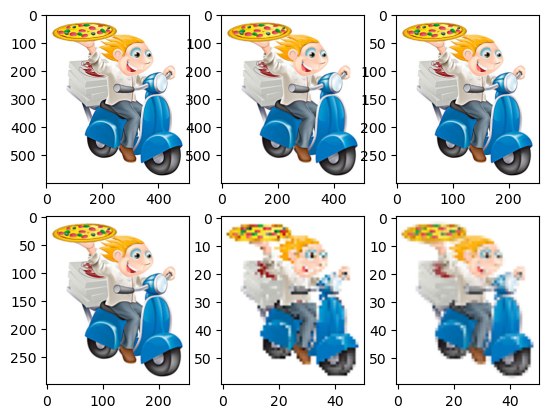

In [2]:
# 自定义卷积操作
# 加载图像
img1 = cv.imread('./images/xiaoren.png')

# 自定义一个 kernel 核
kernel = np.ones((3, 3), np.float32) / 9

# 做卷积操作
# 第 2 个参数为：ddepth，输出图像深度（-1 表示与输入相同）
# 图像深度指单个像素值的存储格式，例如 cv.CV_8U（8 位无符号）
img2 = cv.filter2D(img1, -1, kernel)

# 缩小
h, w, _ = img1.shape  # 高度、宽度
w = int(w * 0.5)
h = int(h * 0.5)
img3 = cv.resize(img1, (w, h))
img4 = cv.resize(img2, (w, h))

w = int(w * 0.2)
h = int(h * 0.2)
img5 = cv.resize(img3, (w, h))  # 缩小
img6 = cv.resize(cv.filter2D(img4, -1, kernel), (w, h))  # 卷积并缩小

# 可视化
plt.subplot(231)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))  # 显示转换后的 RGB 图像

plt.subplot(232)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))  # 卷积 1 次

plt.subplot(233)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))  # 缩小 1 次

plt.subplot(234)
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))  # 卷积 1 次 -> 缩小 1 次

plt.subplot(235)
plt.imshow(cv.cvtColor(img5, cv.COLOR_BGR2RGB))  # 缩小 2 次

plt.subplot(236)
plt.imshow(cv.cvtColor(img6, cv.COLOR_BGR2RGB))  # 卷积并缩小 2 次

# plt.show() 会清空图像缓冲区，导致后续的 savefig() 无法获取图像数据
plt.savefig("./images/a.png")  # 先保存
plt.show()  # 后显示

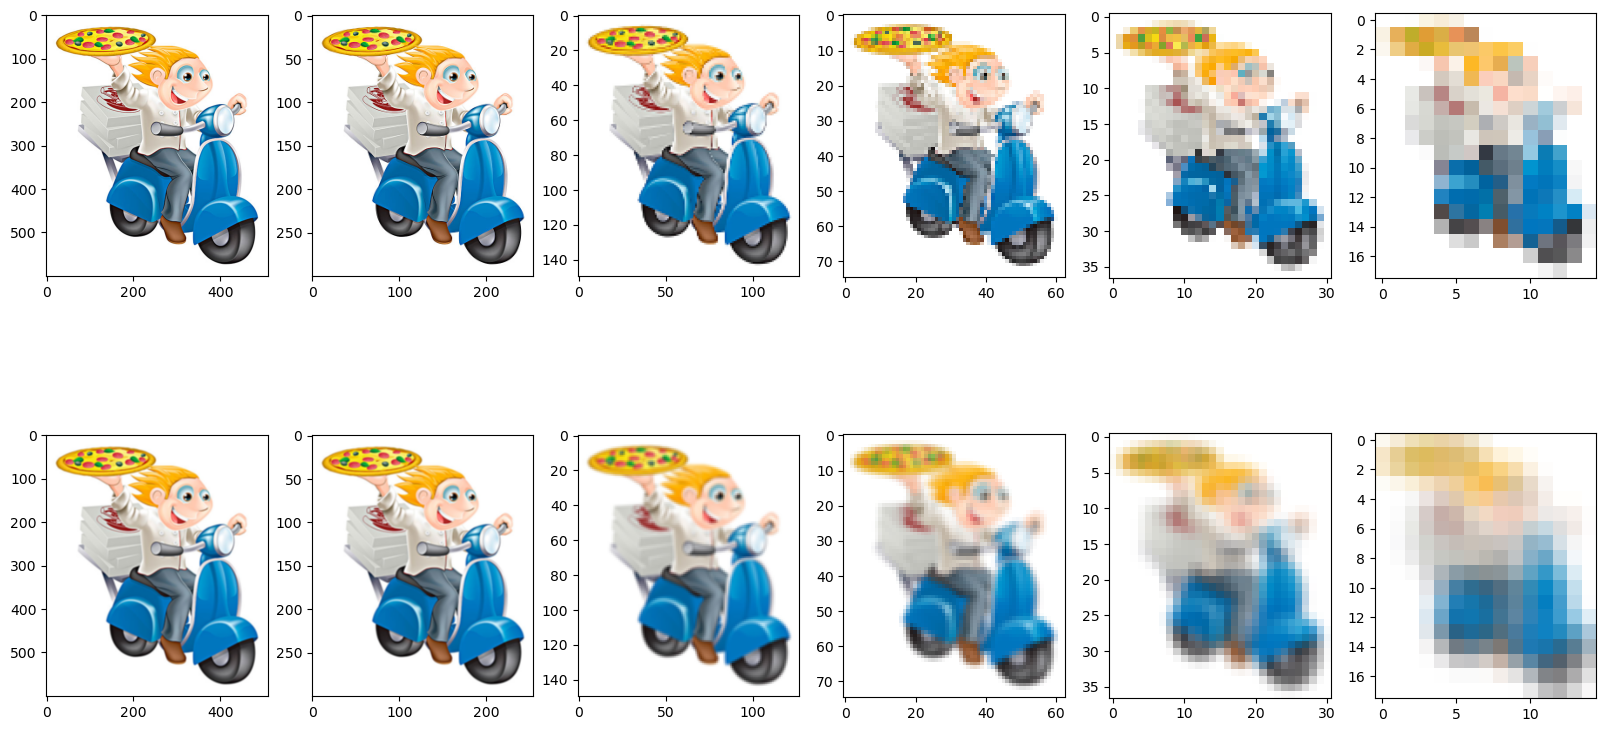

In [3]:
"""高斯模糊"""
# 加载图像
img1 = cv.imread('./images/xiaoren.png')

# ksize=(5, 5)：高斯核大小
# sigmaX=2.0：X方向标准差
# sigmaY=2.0：Y方向标准差（可选，默认等于 sigmaX）
img2 = cv.GaussianBlur(img1, ksize=(5, 5), sigmaX=2.0, sigmaY=2.0)

# 可视化
plt.figure(figsize=(20, 10))

# 显示第 1 列图像
plt.subplot(2, 6, 1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))  # 原图
plt.subplot(2, 6, 7)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))  # 高斯模糊

# 循环缩小图像
for i in range(5):
    h, w, _ = img1.shape  # 高度、宽度
    w = int(w * 0.5)
    h = int(h * 0.5)
    g_img = cv.GaussianBlur(img1, ksize=(5, 5), sigmaX=2.0, sigmaY=2.0)  # 高斯模糊
    img1 = cv.resize(img1, (w, h))  # 缩小图像
    img2 = cv.resize(g_img, (w, h))  # 高斯模糊 + 缩小图像
    plt.subplot(2, 6, i + 2)
    plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
    plt.subplot(2, 6, i + 8)
    plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))

# plt.savefig("./images/a.png")
plt.show()


### 自定义卷积核

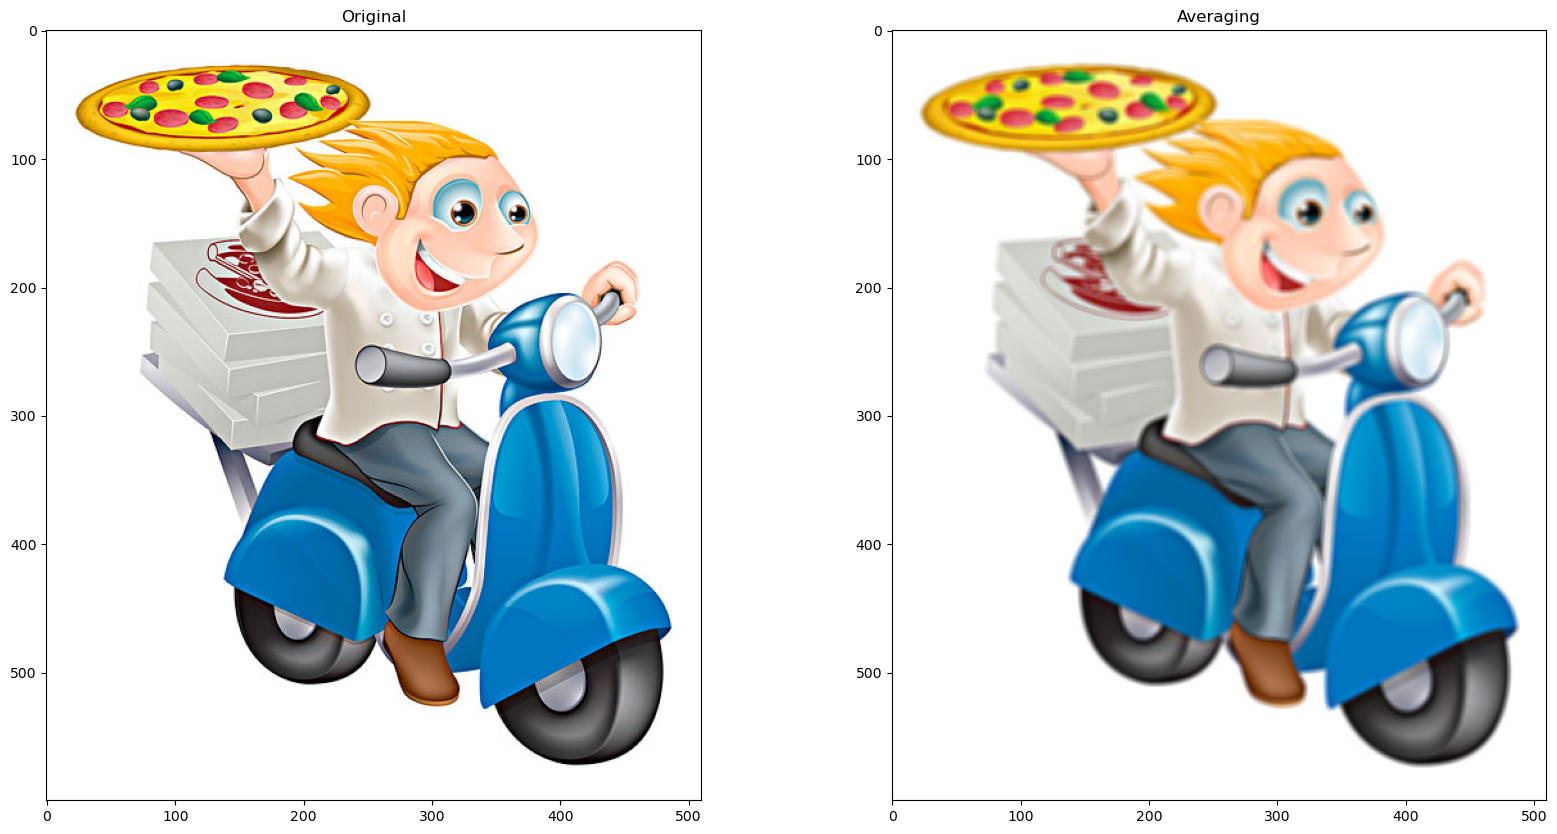

In [4]:
"""均值滤波"""

# 加载图像
img = cv.imread('./images/xiaoren.png')

# 自定义一个 kernel 核
kernel = np.ones((5, 5), np.float32) / 25

# 做卷积操作
# 第 2 个参数为：ddepth，输出图像深度（-1 表示与输入相同）
dst = cv.filter2D(img, -1, kernel)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 均值滤波
plt.title('Averaging')
plt.show()

In [ ]:
"""自定义卷积操作"""

# 加载图像
img = cv.imread('./images/xiaoren.png')

# 自定义一个 kernel 核
kernel = np.array([
    [1, 2, 1],
    [0, -8, 0],
    [1, 2, 1]
], dtype=np.float32)

# 做一个卷积操作
# 第 2 个参数为：ddepth，输出图像深度（-1 表示与输入相同）
dst = cv.filter2D(img, -1, kernel)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 自定义卷积核
plt.title('Define Kernel')
plt.show()

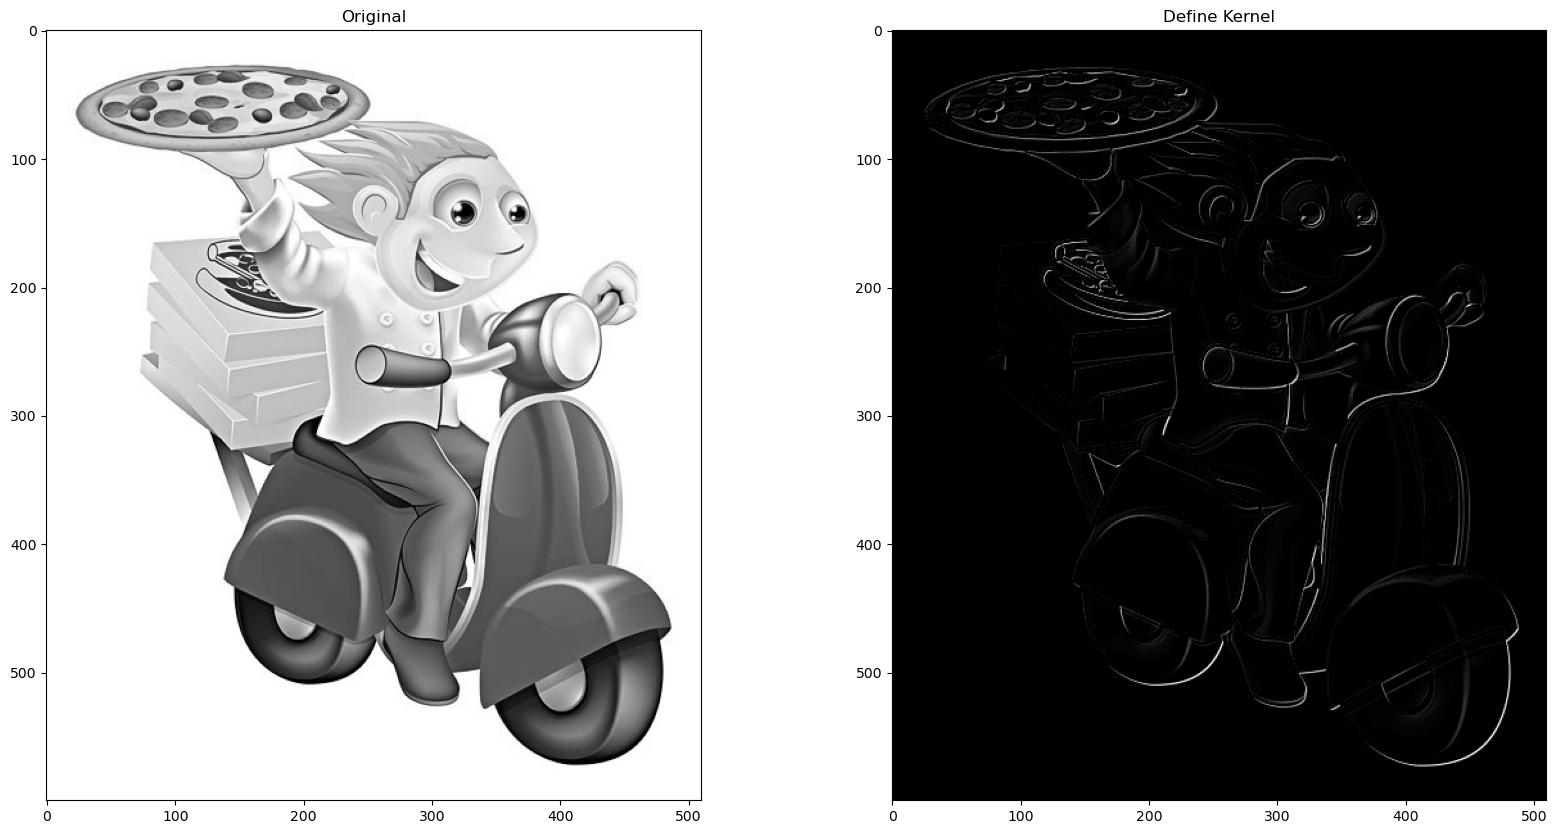

In [6]:
# NOTE：深度学习经常做多步操作，把要的特征保留下来，把不要的特征去掉

# 自定义卷积操作
# 加载灰度图
img = cv.imread('./images/xiaoren.png', 0)

# 自定义一个 kernel 核
kernel = np.array([
    # [-1, -1, -1],
    # [-1,  8, -1],
    # [-1, -1, -1]
    [-1, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
], dtype=np.float32)

# 做卷积操作
# 第 2 个参数为：ddepth，输出图像深度（-1 表示与输入相同）
dst = cv.filter2D(img, -1, kernel)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_GRAY2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_GRAY2RGB))  # 自定义卷积核
plt.title('Define Kernel')
plt.show()

#### 均值滤波  cv.blur(src, ksize, anchor, borderType)
- src:输入图像
- ksize:卷积核的大小
- anchor:默认值(-1,-1)，表示核中心
- borderType:边界类型
- 选择窗口中的所有值的均值作为输出值
- 采用均值滤波模板对图像噪声进行滤除。令 $S_{xy}$ 表示中心在 $(x, y)$ 点，尺寸为 $m \times n$ 的矩形子图像窗口的坐标组。均值滤波器可表示为：

$$\hat{f}(x, y) = \frac{1}{mn} \sum_{(s, t) \in S_{xy}} g(s, t)$$

- 由一个归一化卷积框完成的。它只是用卷积框覆盖区域所有像素的平均值来代替中心元素。

- 例如，3x3标准化的平均过滤器如下所示：

$$K = \frac{1}{9} \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}$$

- 均值滤波的优点是算法简单，计算速度较快，缺点是在去噪的同时去除了很多细节部分，将图像变得模糊。

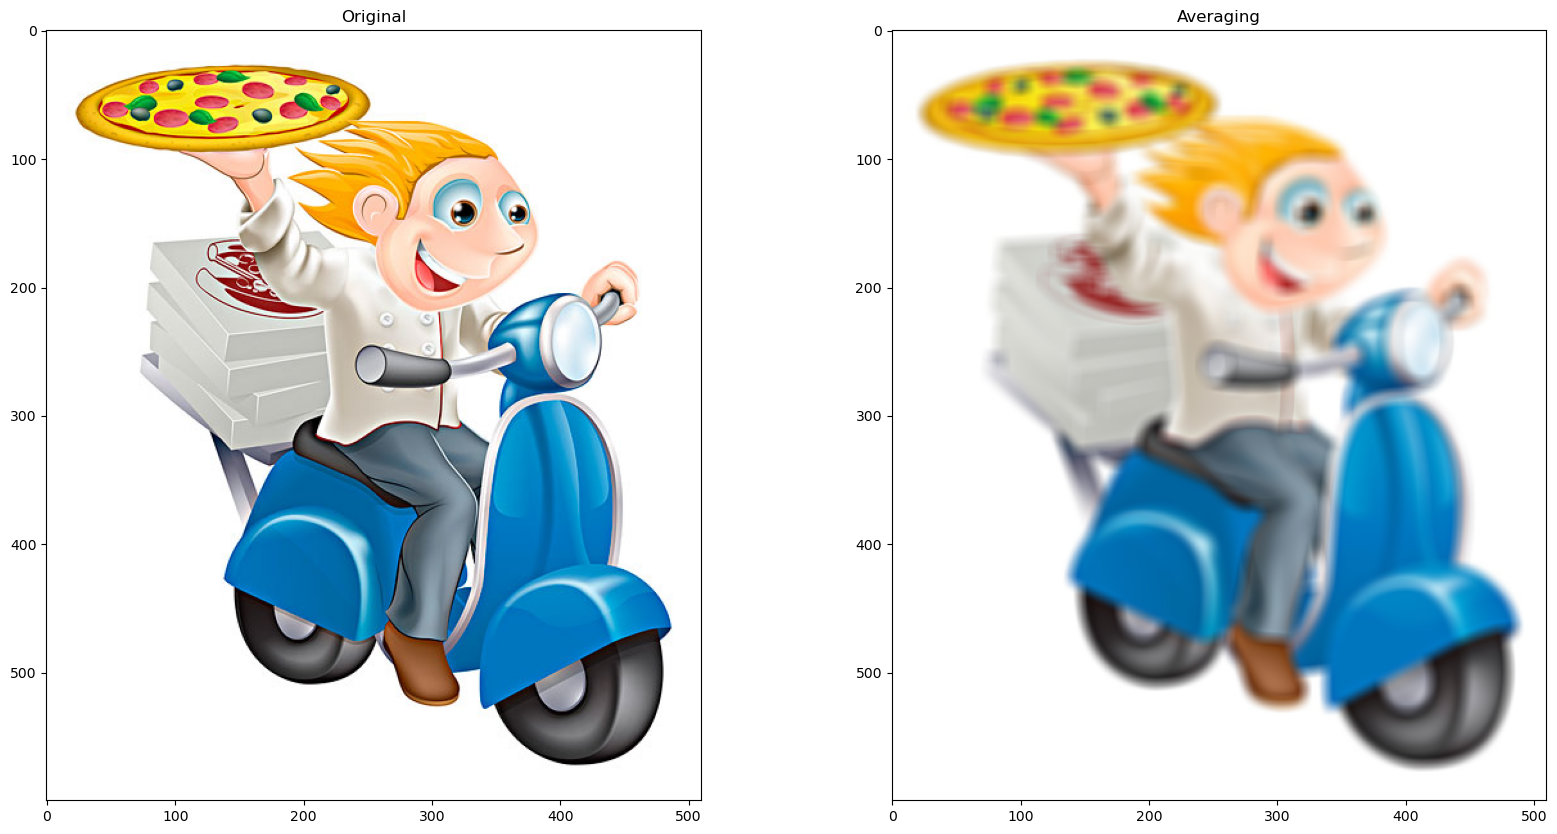

In [7]:
# OpenCV 自带的均值 filter 过滤器
# 加载图像
img = cv.imread('./images/xiaoren.png')

# 做卷积操作
# 核越大，越模糊
dst = cv.blur(img, ksize=(11, 11))

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 均值滤波
plt.title('Averaging')
plt.show()

In [8]:
print(img[75:80, 75:80])  # 原图

[[[  0 206 248]
  [  0 213 249]
  [  0 220 248]
  [  0 220 245]
  [  0 218 243]]

 [[  0 218 242]
  [  0 224 243]
  [  0 222 246]
  [  3 210 248]
  [ 22 206 255]]

 [[ 10 240 255]
  [ 14 230 249]
  [  8 209 236]
  [  0 207 231]
  [  0 227 243]]

 [[ 28  98 205]
  [ 15 196 242]
  [  6 252 255]
  [  6 250 255]
  [ 10 223 250]]

 [[  0   1 157]
  [  0   8 162]
  [  8  58 184]
  [ 14 137 217]
  [  5 186 231]]]


In [9]:
print(dst[75:80, 75:80])  # 平滑后的图像

[[[ 15 177 217]
  [ 14 180 219]
  [ 14 183 221]
  [ 12 187 224]
  [ 13 188 226]]

 [[ 11 180 229]
  [ 11 182 230]
  [ 11 183 230]
  [ 10 184 231]
  [ 10 184 231]]

 [[ 12 176 229]
  [ 11 178 229]
  [ 10 179 229]
  [ 10 180 229]
  [  9 181 229]]

 [[ 13 174 229]
  [ 13 176 229]
  [ 12 177 229]
  [ 11 178 229]
  [ 11 179 229]]

 [[ 15 173 229]
  [ 14 175 229]
  [ 14 176 230]
  [ 13 177 230]
  [ 13 178 230]]]


### 高斯滤波  cv2.GaussianBlur(src,ksize,sigmaX,sigmay,borderType)

- src: 输入图像
- ksize:高斯卷积核的大小，注意:卷积核的宽度和高度都应为奇数，且可以不同
- sigmaX: 水平方向的标准差
- sigmaY: 垂直方向的标准差，默认值为0，表示与sigmaX相同
- borderType:填充边界类型

二维高斯是构建高斯滤波器的基础，其概率分布函数如下所示：

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left\{-\frac{x^2 + y^2}{2\sigma^2}\right\}$$

$G(x,y)$ 的分布是一个突起的帽子的形状。这里的 $\sigma$ 可以看作两个值，一个是 $x$ 方向的标准差 $\sigma_x$，另一个是 $y$ 方向的标准差 $\sigma_y$。

窗口滤波过程中对应的卷积参数是通过高斯函数计算出来的，特点是中间区域的权重系数大，而周边区域的权重系数小。

作用：去除高斯噪声数据（噪声值服从正态/高斯分布）以及图像模糊化操作。

![高斯滤波](picture/高斯滤波.png)

当 $\sigma_x$ 和 $\sigma_y$ 取值越大，整个形状越近于扁平；当 $\sigma_x$ 和 $\sigma_y$ 整个形状越突起。

正态分布是一种钟形曲线，越接近中心，取值越大，越远离中心，取值越小。计算平滑结果时，只需要将"中心点"作为原点，其他点按照其在正态曲线上的位置，分配权重，就可以得到一个加权平均值。

高斯平滑在从图像中去除高斯噪声方面非常有效。

高斯平滑的流程：

- 首先确定权重矩阵

假定中心点的坐标是 $(0,0)$ ，那么距离它最近的8个点的坐标如下：

![权重矩阵](picture/权重矩阵.png)

更远的点以此类推。

为了计算权重矩阵，需要设定$\sigma$的值。假定$\sigma$=1.5，则模糊半径为1的权重矩阵如下:

![权重矩阵2](picture/权重矩阵2.png)

这9个点的权重总和等于0.4787147，如果只计算这9个点的加权平均，还必须让它们的权重之和等于1，因此上面9个值还要分别除以0.4787147，得到最终的权重矩阵。

![权重矩阵3](picture/权重矩阵3.png)

- 计算高斯模糊

有了权重矩阵，就可以计算高斯模糊的值了。

假设现有9个像素点，灰度值(0-255)如下:

![权重矩阵4](picture/权重矩阵4.png)

每个点乘以对应的权重值:

![权重矩阵5](picture/权重矩阵5.png)

得到

![权重矩阵6](picture/权重矩阵6.png)

将这9个值加起来，就是中心点的高斯模糊的值。对所有点重复这个过程，就得到了高斯模糊后的图像。如果原图是彩色图片，可以对RGB三个通道分别做高斯平滑。


In [10]:
# 查看高斯卷积 kernel
# ksize=5：窗口大小为 5×1
# sigma=1：标准差为 1
# 归一化：生成的权重会归一化，确保总和为 1（避免图像亮度偏移）
a = cv.getGaussianKernel(ksize=5, sigma=1, ktype=cv.CV_64F)
print("一维高斯核：\n", a, sep="")

kernel = np.dot(a, a.T)
print("\n二维高斯核：\n", kernel, sep="")

一维高斯核：
[[0.05448868]
 [0.24420134]
 [0.40261995]
 [0.24420134]
 [0.05448868]]

二维高斯核：
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


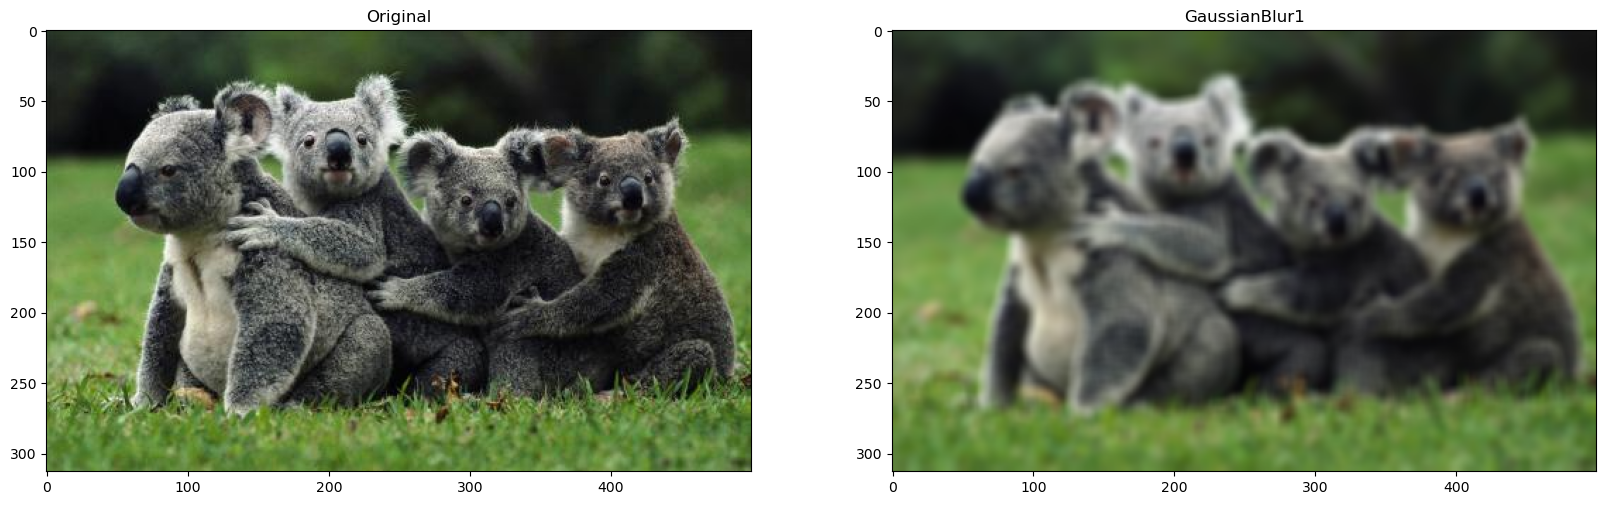

In [11]:
# OpenCV 自带的高斯 filter 过滤器
# 加载图像
img = cv.imread('./images/koala.png')

# 做卷积操作
# ksize：给定窗口大小
# sigmaX: 给定横向的 kernel 中，参数的标准差
# sigmaY: 纵向标准差
# 标准差越大，越模糊
dst = cv.GaussianBlur(img, ksize=(9, 9), sigmaX=5.0, sigmaY=5.0)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 高斯模糊
plt.title('GaussianBlur1')
plt.show()

垂直高斯核：
[[0.02763055]
 [0.06628225]
 [0.12383154]
 [0.18017382]
 [0.20416369]
 [0.18017382]
 [0.12383154]
 [0.06628225]
 [0.02763055]]

水平高斯核：
[[0.02763055 0.06628225 0.12383154 0.18017382 0.20416369 0.18017382
  0.12383154 0.06628225 0.02763055]]


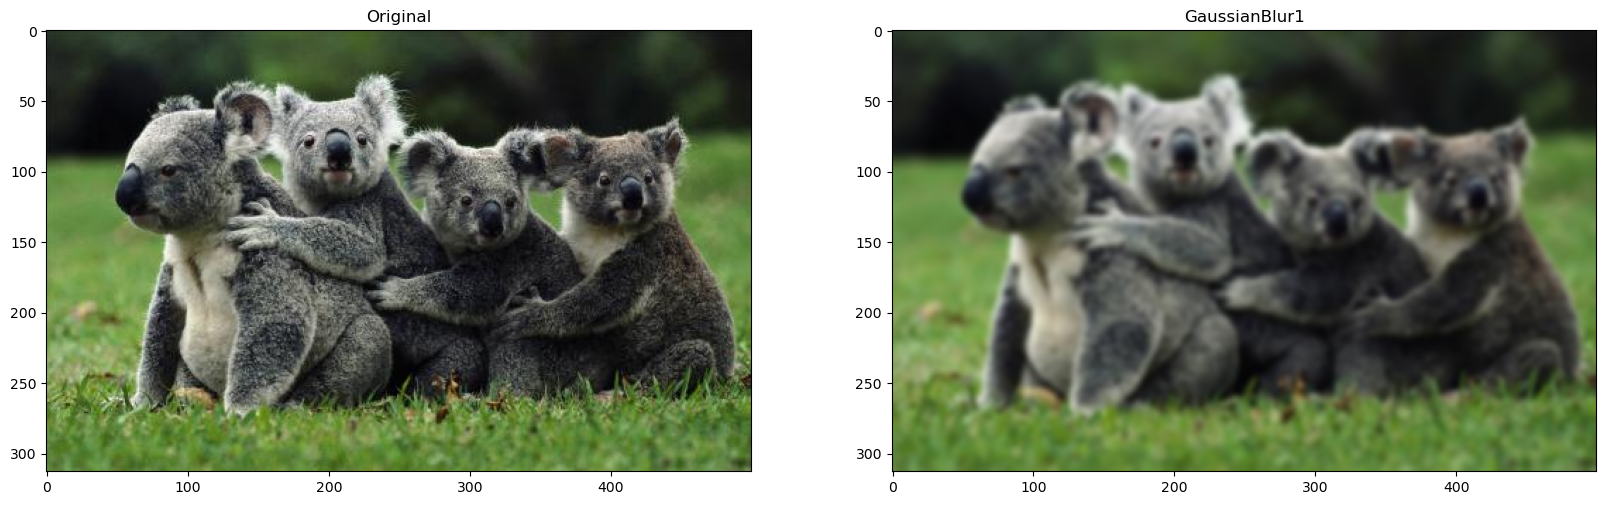

In [12]:
# 定义卷积核
kernel1 = cv.getGaussianKernel(ksize=9, sigma=2, ktype=cv.CV_64F)
print("垂直高斯核：\n", kernel1, sep="")
kernel2 = np.transpose(kernel1)
print("\n水平高斯核：\n", kernel2, sep="")

# 加载图像
img = cv.imread('./images/koala.png')

# 做二次卷积操作
# 第 2 个参数为：ddepth，输出图像深度（-1 表示与输入相同）
dst = cv.filter2D(cv.filter2D(img, -1, kernel1), -1, kernel2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 高斯模糊
plt.title('GaussianBlur1')
plt.show()

### 中值滤波  cv.medianBlur(src,ksize)
- src:输入图像
- ksize:卷积核的大小
- 选择窗口区域中的中值作为输出值

中值滤波是一种典型的非线性滤波技术，基本思想是用像素点邻域灰度值的中值来代替该像素点的灰度值。中值滤波对椒盐噪声(salt-and-pepper noise)来说尤其有用，因为它不依赖于邻域内那些与典型值差别很大的值。

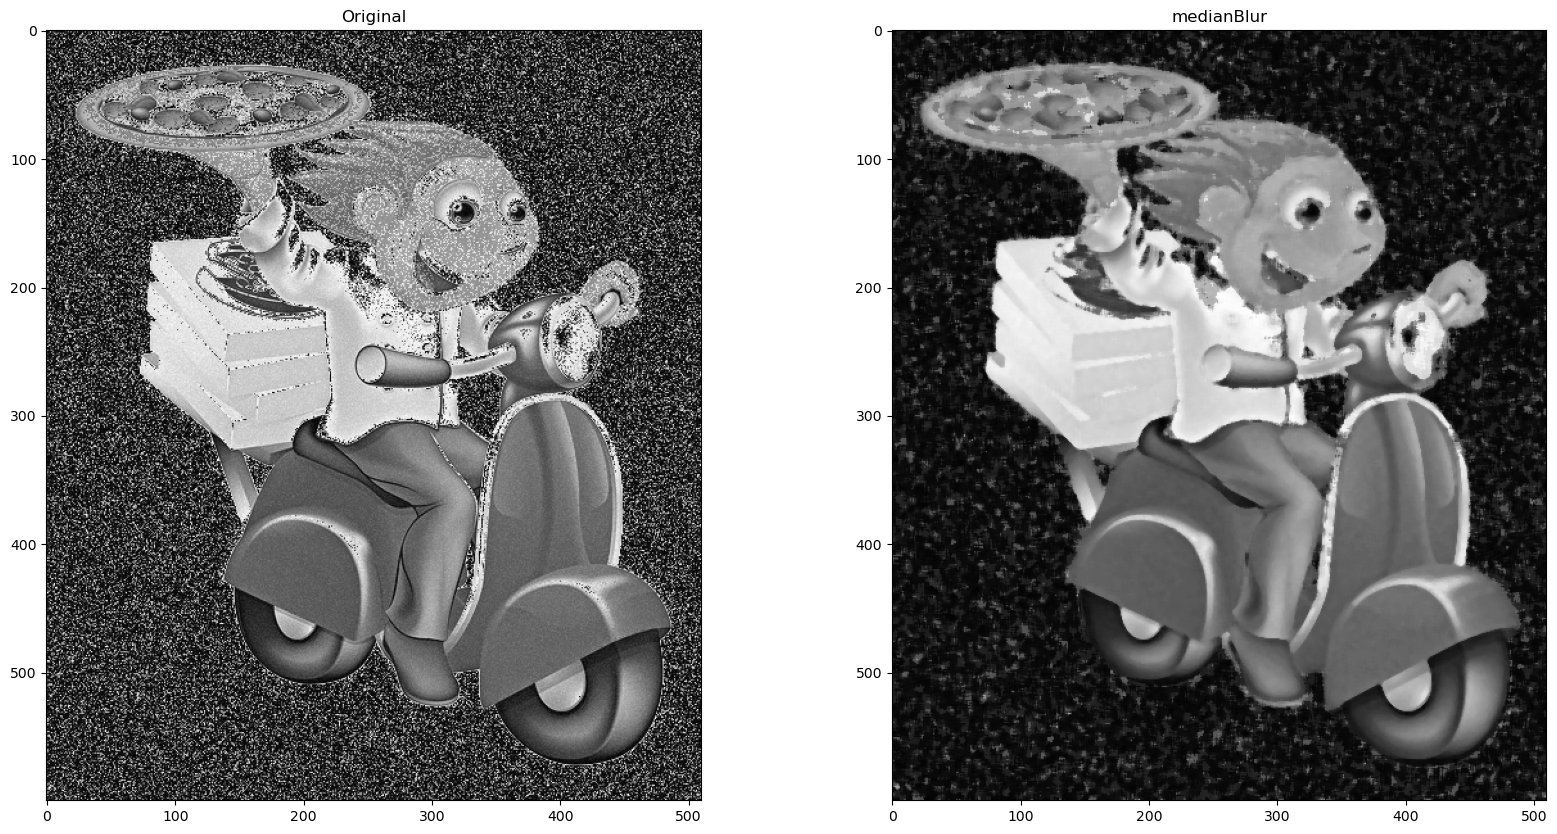

In [13]:
# NOTE：深度学习不再决定使用什么滤波（选什么参数），让模型决定使用什么参数

# 中值过滤
# 去除椒盐噪声：随机出现的纯白（盐噪声）或纯黑（胡椒噪声）像素点

# 加载图像
img = cv.imread('./images/xiaoren.png')

# 加噪声
# 从正态分布中抽取的随机样本，均值和标准差都为 10
noisy_img = np.random.normal(10, 10, (img.shape[0], img.shape[1], img.shape[2]))
# 截取 0-255 的值
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
# 合成原图和噪声图
img = img + noisy_img

# 转换为灰度图
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做一个中值过滤
# ksize=5：窗口大小为 5×5
dst = cv.medianBlur(img, ksize=5)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(img, 'gray')
plt.title('Original')

plt.subplot(122)
plt.imshow(dst, 'gray')  # 中值过滤
plt.title('medianBlur')
plt.show()

### 双边滤波
提取图像的纹理、条纹信息

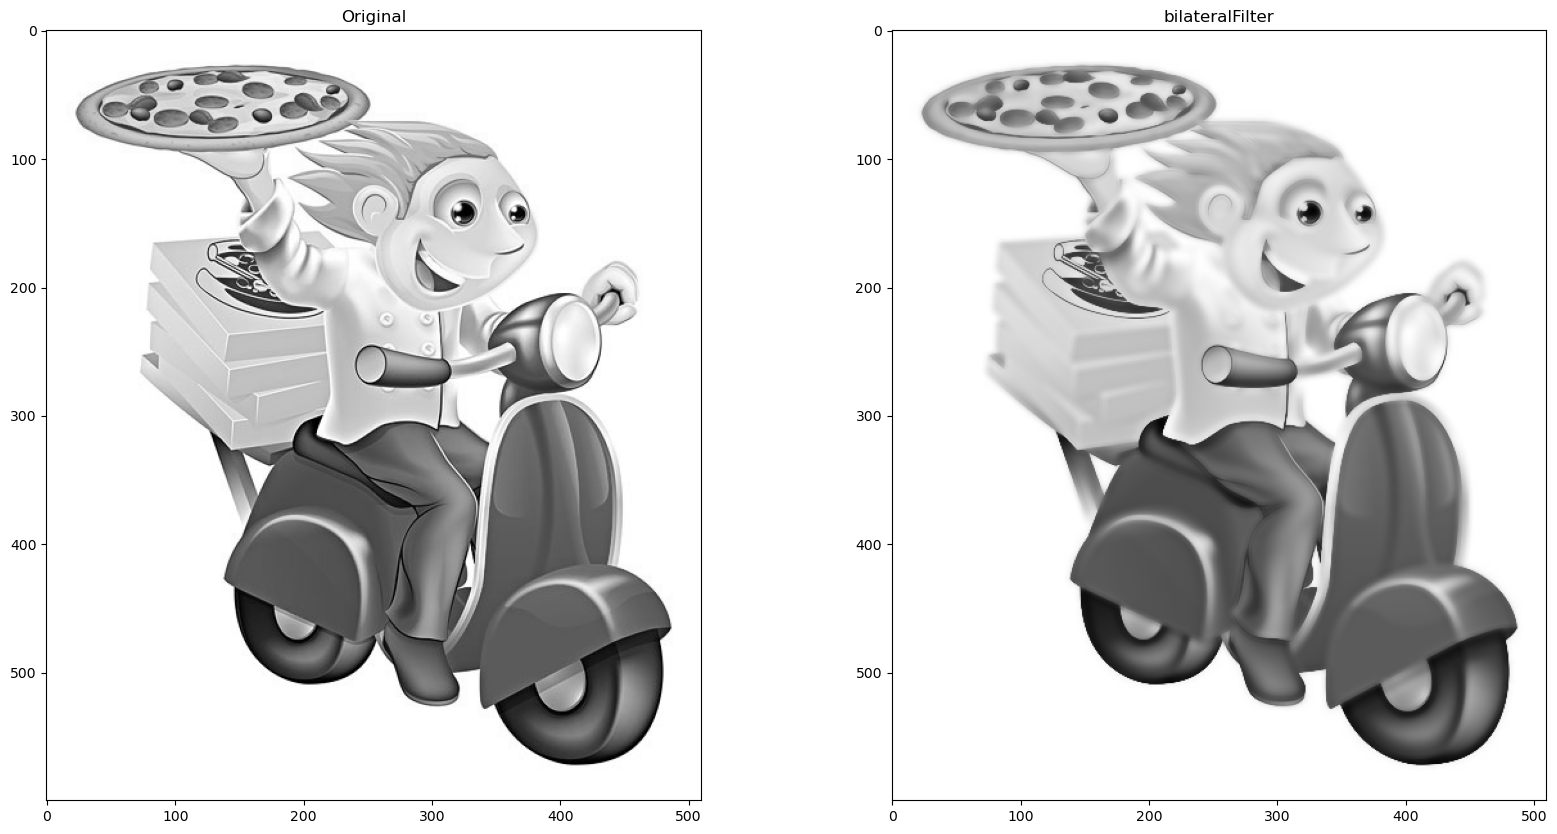

In [14]:
# 双边滤波: 中间的纹理删除，保留边缘信息

# 加载图像
img = cv.imread('./images/xiaoren.png')
# 转成灰度图
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做双边滤波
# d=9：滤波时考虑的邻域直径
# sigmaColor=75：颜色空间的标准差，值越大，颜色差异容忍度越高
# sigmaSpace=75：坐标空间的标准差，值越大，远处像素影响越大
dst = cv.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))  # 双边滤波
plt.title('bilateralFilter')
plt.show()